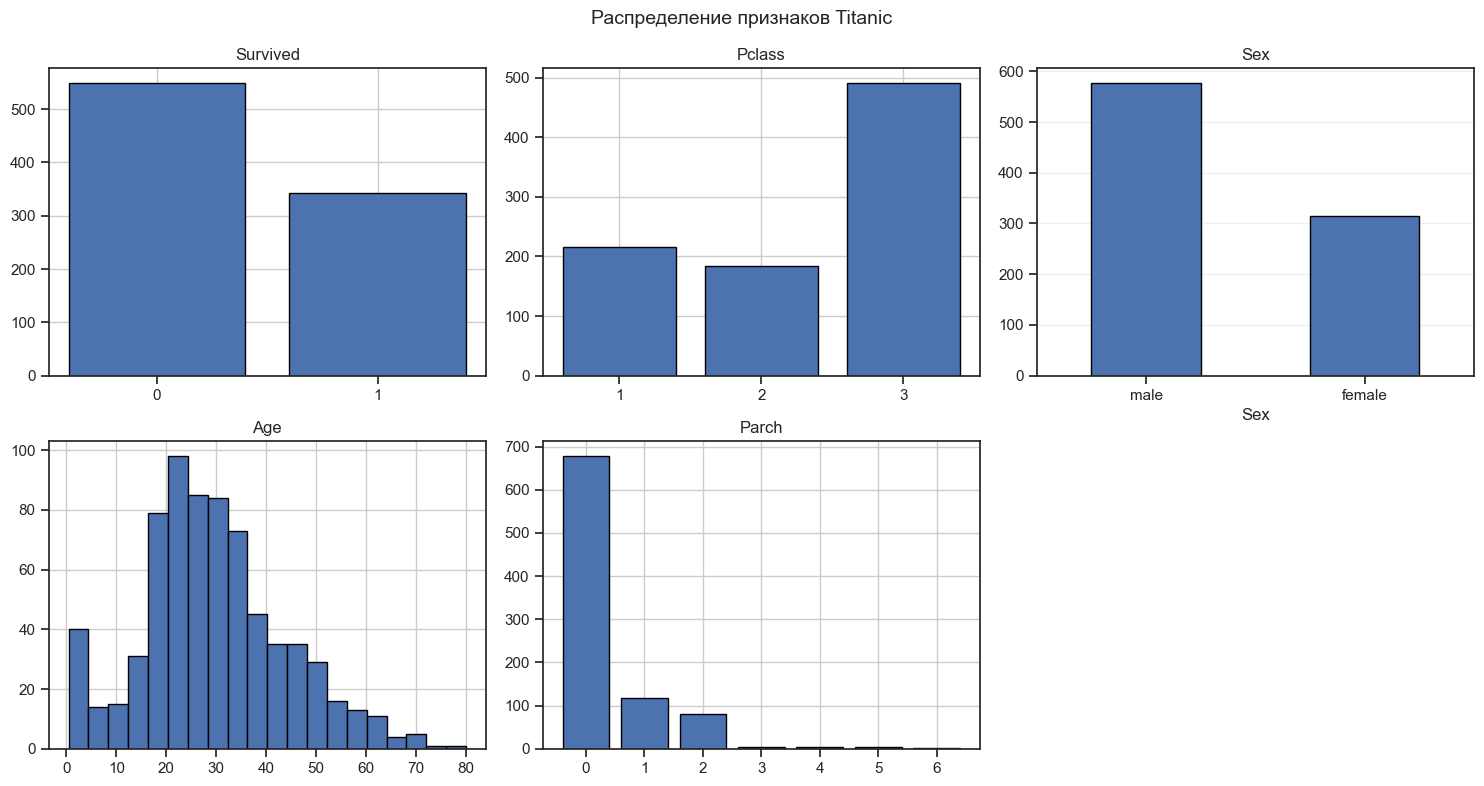

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from pyprojroot import here

df = pd.read_csv(here('src/data/train.csv'))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Распределение признаков Titanic', fontsize=14)

df['Survived'].hist(ax=axes[0,0], bins=[-0.5, 0.5, 1.5], rwidth=0.8, edgecolor='black')
axes[0,0].set_title('Survived')
axes[0,0].set_xticks([0, 1])

df['Pclass'].hist(ax=axes[0,1], bins=[0.5, 1.5, 2.5, 3.5], rwidth=0.8, edgecolor='black')
axes[0,1].set_title('Pclass')
axes[0,1].set_xticks([1, 2, 3])

df['Sex'].value_counts().plot(kind='bar', ax=axes[0,2], edgecolor='black', rot=0)
axes[0,2].set_title('Sex')
axes[0,2].grid(axis='y', alpha=0.3)

df['Age'].hist(ax=axes[1,0], bins=20, edgecolor='black')
axes[1,0].set_title('Age')

df['Parch'].hist(ax=axes[1,1], bins=range(8), align='left', rwidth=0.8, edgecolor='black')
axes[1,1].set_title('Parch')

fig.delaxes(axes[1,2])

plt.tight_layout()
plt.show()

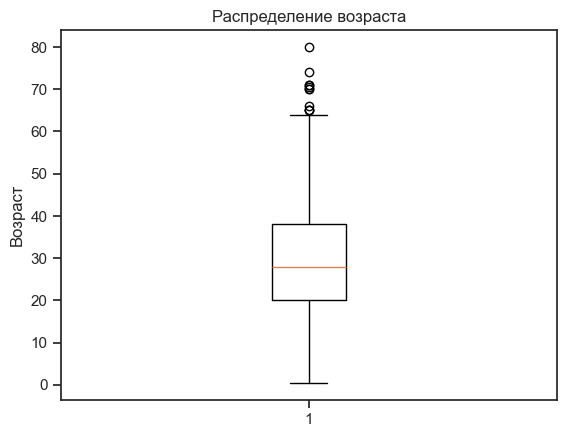

In [32]:
fig, axes = plt.subplots()
axes.boxplot(df['Age'].dropna(), showbox=True, meanline=True)
axes.set_title('Распределение возраста')
axes.set_ylabel('Возраст')
plt.show()

#Возраст пассажиров распеределяется в большей степени в сторону молодых людей. 
#Медианный возраст 28 лет. 
#Центральные 50% выборки находятся в возрастном диапазоне примерно от 20 до 40 лет. 
#Минимальный возраст близок к 0
#верхняя граница нормы заканчивается на уровне примерно 64 года

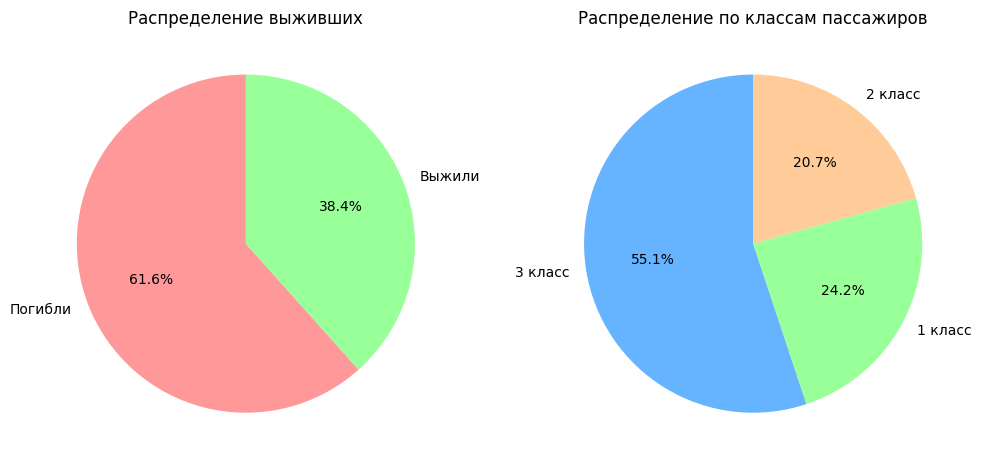

In [23]:

survived_counts = df['Survived'].value_counts()
pclass_counts = df['Pclass'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

labels_surv = ['Погибли', 'Выжили'] if set(survived_counts.index) == {0, 1} else survived_counts.index
ax1.pie(survived_counts, labels=labels_surv, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#99ff99'])
ax1.set_title('Распределение выживших')

labels_class = [f'{x} класс' for x in pclass_counts.index]
ax2.pie(pclass_counts, labels=labels_class, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99','#ffcc99'])
ax2.set_title('Распределение по классам пассажиров')

plt.show()

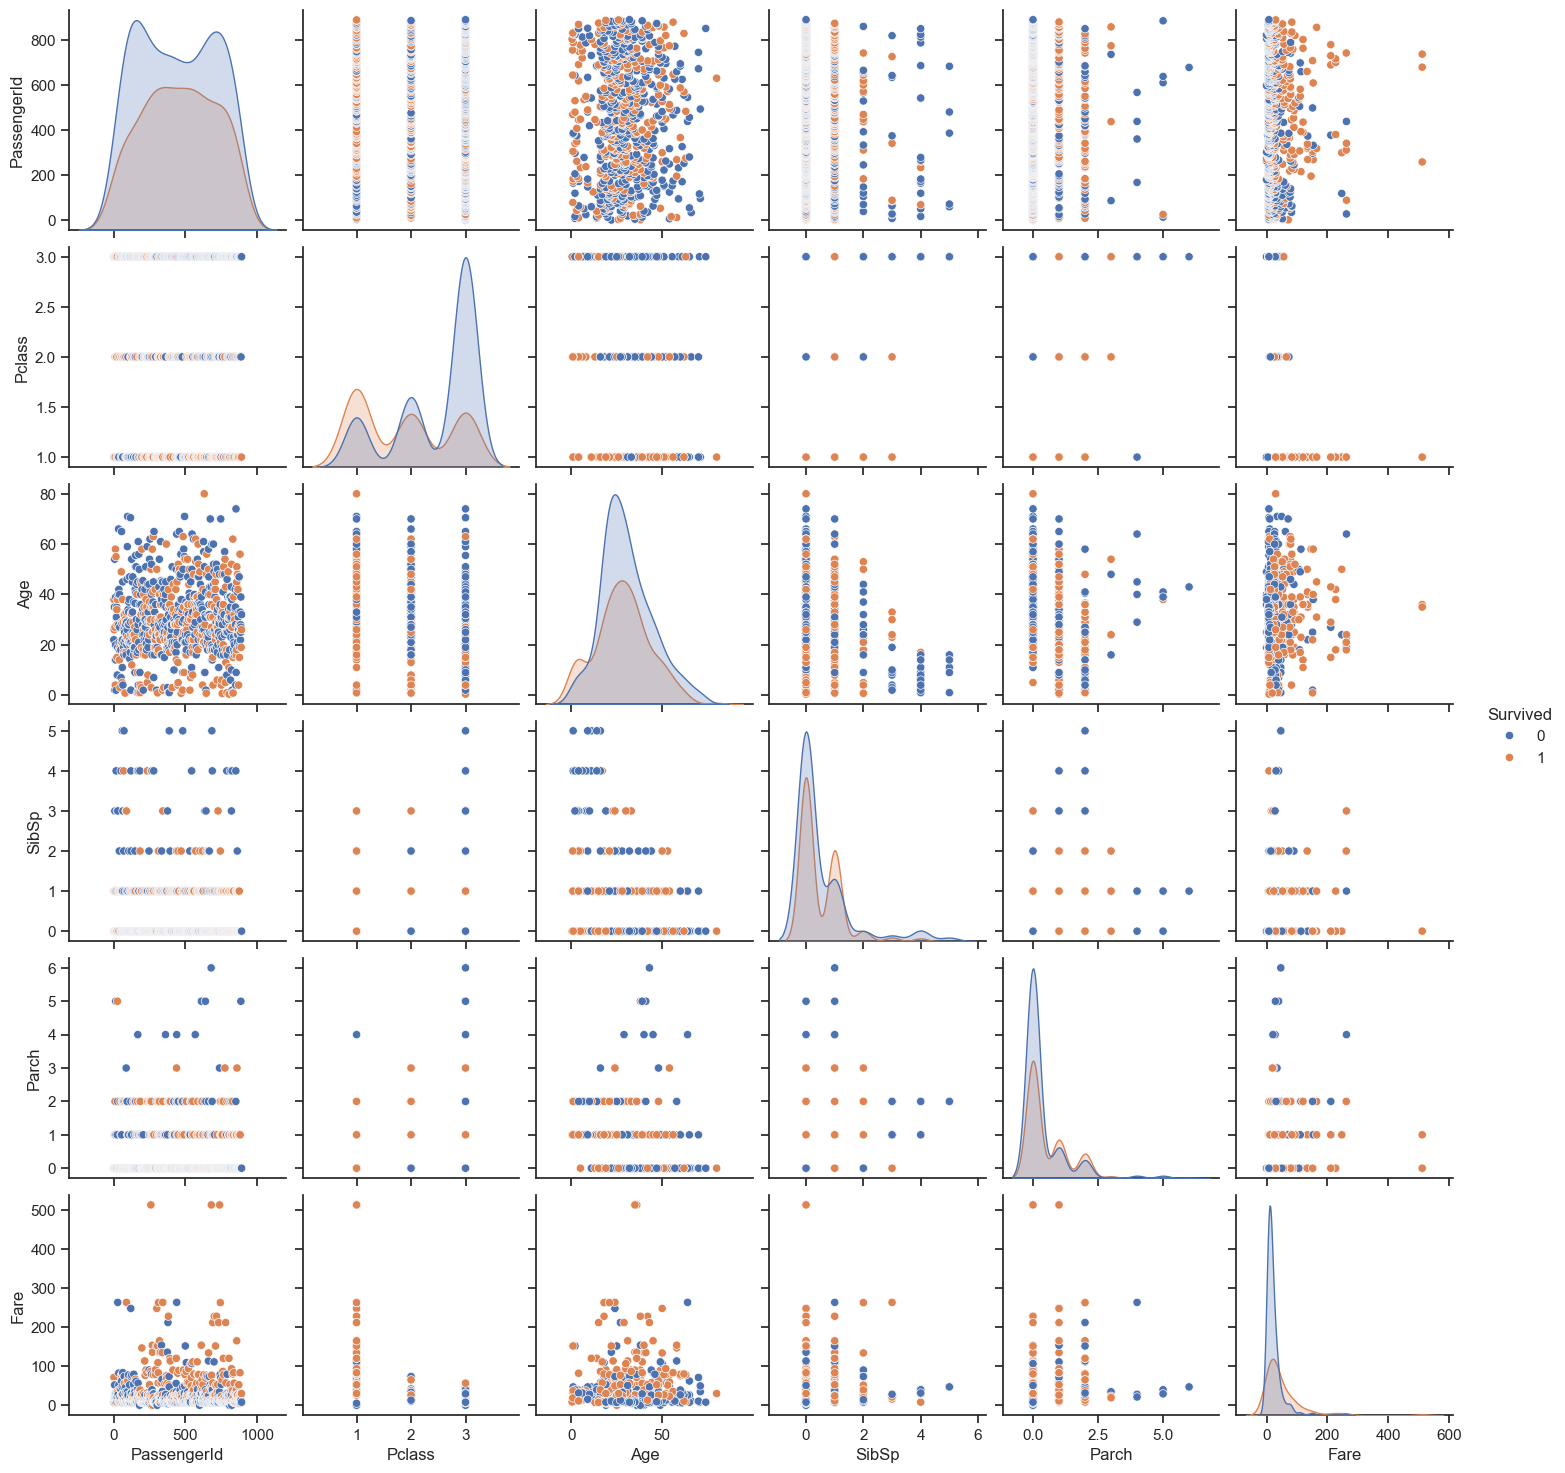

In [27]:
import seaborn as sns

sns.set_theme(style="ticks")

# Строим pairplot для всех числовых переменных
# Очищаем данные от NaN в процессе, чтобы графики построились корректно
g = sns.pairplot(df.dropna(subset=['Age', 'Fare']), hue='Survived')

# Отображаем график
plt.show()

In [37]:
import plotly.express as px

# Создаем интерактивный Sunburst plot
# path=['Pclass', 'Sex'] задает иерархию: сначала класс, внутри него — пол
fig = px.sunburst(
    df, 
    path=['Pclass', 'Sex'], 
    title='Иерархия пассажиров: Класс каюты -> Пол',
    color='Pclass'
)

fig.update_traces(textinfo="label+percent parent+value")

fig.show()